In [9]:

import pandas as pd
import bt as bt
import yfinance as yf
import matplotlib
import datetime as dt
import numpy as np
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
from scipy.optimize import minimize
%matplotlib inline
plt.style.use("dark_background")

In [10]:
inicio = dt.date(2010, 1, 1)
final = dt.date(2025, 5, 30)

carteira = ["VALE3", "ABCB4", "ITUB4", "BBAS3", "BBSE3", "CMIG4", "PETR4", 'CSMG3', 'VBBR3']
#np.setdiff1d(carteira_vo, carteira_vo_v2) # -> verifica a diferença entre as carteiras 1 e 2

carteira = [acao + ".SA" for acao in carteira]

precos = yf.download(carteira, inicio, final)['Close']
precos.dropna(inplace=True)

data = bt.get(carteira, start='2010-01-01', end='2025-05-30')
##ver como converter inicio e final de date para string


C:\Users\adm\AppData\Local\Temp\ipykernel_17976\3247088322.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  precos = yf.download(carteira, inicio, final)['Close']
[*********************100%***********************]  9 of 9 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [11]:
retornos = data.pct_change().apply(lambda x: np.log(1+x)).dropna()
media_retornos = retornos.mean()
matriz_cov = retornos.cov() 

In [12]:
# Passo 1: Calcular os pesos otimizados
precos = data.copy()
retornos = precos.pct_change().apply(lambda x: np.log(1 + x)).dropna()
media_retornos = retornos.mean()
matriz_cov = retornos.cov()

# Configurações
numero_carteiras = 1000000
tabela_retornos_esperados = np.zeros(numero_carteiras)
tabela_volatilidades_esperadas = np.zeros(numero_carteiras)
tabela_sharpe = np.zeros(numero_carteiras)
tabela_pesos = np.zeros((numero_carteiras, len(precos.columns)))

# Simulação de carteiras
for k in range(numero_carteiras):
    pesos = np.random.random(len(precos.columns))
    pesos = pesos / np.sum(pesos)
    tabela_pesos[k, :] = pesos
    
    tabela_retornos_esperados[k] = np.sum(media_retornos * pesos * 252)
    tabela_volatilidades_esperadas[k] = np.sqrt(np.dot(pesos.T, np.dot(matriz_cov * 252, pesos)))
    tabela_sharpe[k] = tabela_retornos_esperados[k] / tabela_volatilidades_esperadas[k]

# Carteira com Sharpe máximo
indice_do_sharpe_maximo = tabela_sharpe.argmax()
pesos_otimizados = tabela_pesos[indice_do_sharpe_maximo]

pesos_otimizados

array([0.1141072 , 0.07424329, 0.00349833, 0.00478716, 0.15166893,
       0.37478514, 0.1338148 , 0.13951628, 0.00357887])

In [13]:
indice_do_sharpe_maximo = tabela_sharpe.argmax()
tabela_pesos[indice_do_sharpe_maximo]

array([0.1141072 , 0.07424329, 0.00349833, 0.00478716, 0.15166893,
       0.37478514, 0.1338148 , 0.13951628, 0.00357887])

In [14]:
df = pd.DataFrame(carteira, columns=['Stock'])
df['Weight'] = pd.DataFrame(tabela_pesos[indice_do_sharpe_maximo])
df

,Stock,Weight
0,VALE3.SA,0.114107
1,ABCB4.SA,0.074243
2,ITUB4.SA,0.003498
3,BBAS3.SA,0.004787
4,BBSE3.SA,0.151669
5,CMIG4.SA,0.374785
6,PETR4.SA,0.133815
7,CSMG3.SA,0.139516
8,VBBR3.SA,0.003579


In [15]:
data = bt.get(carteira, start='2010-01-01', end='2025-05-30')

In [ ]:

# Converter para dicionário (formato necessário para WeighSpecified)
ativos = precos.columns
pesos_dicionario = dict(zip(ativos, pesos_otimizados))

#estratégia rebalanceando a carteira mensalmente
strategy1 = bt.Strategy('Rebalanceando',
                       [bt.algos.RunMonthly(),
                        bt.algos.SelectAll(),
                        bt.algos.WeighSpecified(**pesos_dicionario),
                        bt.algos.Rebalance()])
#estratégia comprando a carteira apenas uma vez
strategy2 = bt.Strategy('BuyHold', 
                   [ bt.algos.RunOnce(),
                     bt.algos.SelectAll(),
                     bt.algos.WeighSpecified(**pesos_dicionario),
                     bt.algos.Rebalance()]
                    )
#com pesos iguais
strategy3 = bt.Strategy('RB Equal',
                       [bt.algos.RunMonthly(),
                        bt.algos.SelectAll(),
                        bt.algos.WeighEqually(),
                        bt.algos.Rebalance()])

strategy4 = bt.Strategy('BH Equal', 
                   [ bt.algos.RunOnce(),
                     bt.algos.SelectAll(),
                     bt.algos.WeighEqually(),
                     bt.algos.Rebalance()]
                    )

Pesos otimizados: {'vale3sa': 0.11410719928339742, 'abcb4sa': 0.07424328808152483, 'itub4sa': 0.00349832550928717, 'bbas3sa': 0.004787163314287198, 'bbse3sa': 0.15166892627818132, 'cmig4sa': 0.3747851432548025, 'petr4sa': 0.1338148041041911, 'csmg3sa': 0.13951627689530224, 'vbbr3sa': 0.003578873279026182}


In [17]:
# Passo 3: Criar e rodar os backtests
st1 = bt.Backtest(strategy1, data)
st2 = bt.Backtest(strategy2, data)
st3 = bt.Backtest(strategy3, data)
st4 = bt.Backtest(strategy4, data)

# Rodar os backtests para as três estratégias
result = bt.run(st1, st2, st3, st4)

100%|██████████| 4/4 [00:03<00:00,  1.21it/s]


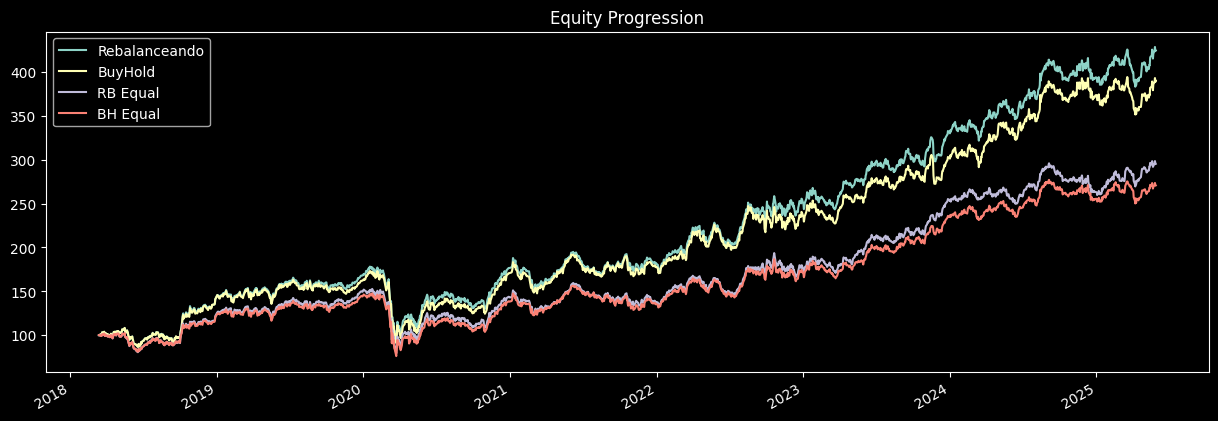

In [18]:

#comando para permitir que os gráficos sejam mostrados

plt.ioff()

# plotando a curva de rentabilidade da carteira
result.plot()

plt.show()

In [19]:
# estatísticas consolidadas
result.display()

Stat                 Rebalanceando    BuyHold     RB Equal    BH Equal
-------------------  ---------------  ----------  ----------  ----------
Start                2018-03-13       2018-03-13  2018-03-13  2018-03-13
End                  2025-05-29       2025-05-29  2025-05-29  2025-05-29
Risk-free rate       0.00%            0.00%       0.00%       0.00%

Total Return         324.37%          290.03%     195.23%     170.62%
Daily Sharpe         0.92             0.86        0.74        0.69
Daily Sortino        1.46             1.36        1.16        1.08
CAGR                 22.19%           20.77%      16.20%      14.80%
Max Drawdown         -47.06%          -47.44%     -48.10%     -48.46%
Calmar Ratio         0.47             0.44        0.34        0.31

MTD                  3.25%            4.14%       1.30%       1.84%
3m                   3.95%            2.41%       6.96%       2.50%
6m                   3.71%            0.21%       7.30%       1.77%
YTD                  7.77%

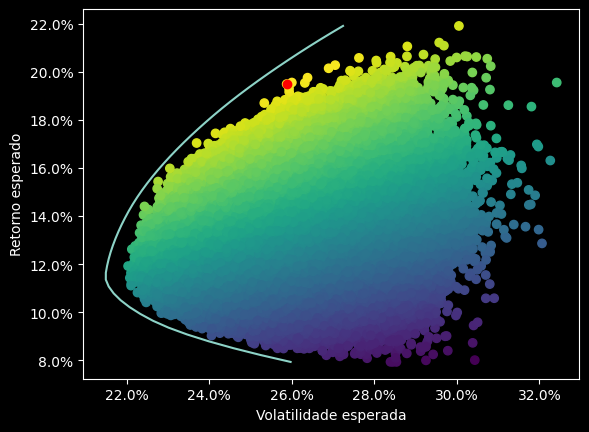

In [20]:
tabela_retornos_esperados_arit = np.exp(tabela_retornos_esperados) - 1
eixo_y_fronteira_eficiente = np.linspace(tabela_retornos_esperados_arit.min(),
tabela_retornos_esperados_arit.max(), 50)

def pegando_retorno(peso_teste):
    peso_teste = np.array(peso_teste)
    retorno = np.sum(media_retornos * peso_teste) * 252
    retorno = np.exp(retorno) - 1

    return retorno

def checando_soma_pesos(peso_teste):

    return np.sum(peso_teste)-1

def pegando_vol(peso_teste):
    peso_teste = np.array(peso_teste)
    vol = np.sqrt(np.dot(peso_teste.T, np.dot(matriz_cov*252, peso_teste)))
    
    return vol

peso_inicial = [1/len(carteira)] * len(carteira) 
limites = tuple([(0, 1) for ativo in carteira])

eixo_x_fronteira_eficiente = []

for retorno_possivel in eixo_y_fronteira_eficiente:
    
    restricoes = ({'type':'eq', 'fun':checando_soma_pesos},
            {'type':'eq', 'fun': lambda w: pegando_retorno(w) - retorno_possivel})
    
    result = minimize(pegando_vol,peso_inicial,method='SLSQP', bounds=limites, 
                      constraints=restricoes)
    eixo_x_fronteira_eficiente.append(result['fun'])
fig, ax = plt.subplots()

ax.scatter(tabela_volatilidades_esperadas, tabela_retornos_esperados_arit, c = tabela_sharpe)
plt.xlabel("Volatilidade esperada")
plt.ylabel("Retorno esperado")
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.scatter(tabela_volatilidades_esperadas[indice_do_sharpe_maximo], 
            tabela_retornos_esperados_arit[indice_do_sharpe_maximo], c = "red")
ax.plot(eixo_x_fronteira_eficiente, eixo_y_fronteira_eficiente)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

plt.show()